In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [1]:
import duckdb

files = [
    "aisdk-2025-05-15.csv",
    "aisdk-2025-05-16.csv",
    "aisdk-2025-05-17.csv",
    "aisdk-2025-05-18.csv"
]

file_list = ", ".join([f"'{f}'" for f in files])

con = duckdb.connect("ais_work.duckdb")

query = f"""
COPY (
    SELECT * EXCLUDE (rn)
    FROM (
        SELECT *,
               ROW_NUMBER() OVER (
                   PARTITION BY "# Timestamp", MMSI
                   ORDER BY "# Timestamp"
               ) AS rn
        FROM read_csv(
            [{file_list}],
            header = true,
            union_by_name = true,
            delim = ',',
            quote = '"',
            escape = '"',
            null_padding = true,
            strict_mode = false
        )
    ) t
    WHERE rn = 1
) TO 'ais_4days_dedup.csv' (HEADER, DELIMITER ',');
"""

con.execute(query)

print("Baigta: sukurtas failas ais_4days_dedup.csv")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Baigta: sukurtas failas ais_4days_dedup.csv


In [2]:
import pandas as pd

df = pd.read_csv("ais_4days_dedup.csv")
print(df.shape)
print(df.info())

(34954217, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34954217 entries, 0 to 34954216
Data columns (total 26 columns):
 #   Column                          Dtype  
---  ------                          -----  
 0   # Timestamp                     object 
 1   Type of mobile                  object 
 2   MMSI                            int64  
 3   Latitude                        float64
 4   Longitude                       float64
 5   Navigational status             object 
 6   ROT                             float64
 7   SOG                             float64
 8   COG                             float64
 9   Heading                         float64
 10  IMO                             object 
 11  Callsign                        object 
 12  Name                            object 
 13  Ship type                       object 
 14  Cargo type                      object 
 15  Width                           float64
 16  Length                          float64
 17  Type of po

In [3]:
print(df.shape)

(34954217, 26)


In [4]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('#', '', regex=False)
)
df = df.rename(columns={'_timestamp': 'timestamp'})

df['timestamp'] = pd.to_datetime(df['timestamp'], dayfirst=True, errors='coerce')


df = df.drop(columns=['cargo_type'], errors='ignore')
df['ship_type'] = df['ship_type'].str.strip().str.lower()
df = df[df['ship_type'].isin(['cargo', 'tanker'])].copy()

print(df.columns.tolist())

C:\Users\jokub\AppData\Local\Temp\ipykernel_27628\3025262795.py:10: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['timestamp'] = pd.to_datetime(df['timestamp'], dayfirst=True, errors='coerce')


['timestamp', 'type_of_mobile', 'mmsi', 'latitude', 'longitude', 'navigational_status', 'rot', 'sog', 'cog', 'heading', 'imo', 'callsign', 'name', 'ship_type', 'width', 'length', 'type_of_position_fixing_device', 'draught', 'destination', 'eta', 'data_source_type', 'a', 'b', 'c', 'd']


9351138

In [6]:
missing = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_pct': df.isna().mean() * 100
}).sort_values('missing_pct', ascending=False)

print(missing)

                                missing_count  missing_pct
rot                                    769738     8.231490
heading                                199484     2.133259
eta                                    161260     1.724496
cog                                    133317     1.425677
draught                                 68680     0.734456
c                                       52503     0.561461
d                                       50843     0.543709
a                                        8935     0.095550
b                                        6216     0.066473
sog                                       785     0.008395
name                                      634     0.006780
width                                       6     0.000064
length                                      6     0.000064
type_of_mobile                              0     0.000000
timestamp                                   0     0.000000
latitude                                    0     0.0000

In [7]:
# garbage values
for col in ['type_of_mobile', 'ship_type', 'navigational_status',
            'type_of_position_fixing_device', 'destination']:
    if col in df.columns:
        print(f"\n--- {col} ---")
        print(df[col].value_counts(dropna=False).head(20))


--- type_of_mobile ---
type_of_mobile
Class A    9327093
Class B      24045
Name: count, dtype: int64

--- ship_type ---
ship_type
cargo     6890504
tanker    2460634
Name: count, dtype: int64

--- navigational_status ---
navigational_status
Under way using engine        8550751
Moored                         223069
Constrained by her draught     221738
At anchor                      130909
Restricted maneuverability     109390
Unknown value                   98310
Not under command               15751
Aground                          1038
Under way sailing                 182
Name: count, dtype: int64

--- type_of_position_fixing_device ---
type_of_position_fixing_device
GPS                     8646289
Combined GPS/GLONASS     287994
Internal                 259718
Undefined                148683
GLONASS                    8454
Name: count, dtype: int64

--- destination ---
destination
PLGDN             202596
SEGOT             197664
NLRTM             156921
BEANR             106874

In [8]:
print(df['type_of_mobile'].value_counts(dropna=False))

pd.crosstab(
    df['type_of_mobile'],
    df['sog'].isna(),
    normalize='index'
) * 100

type_of_mobile
Class A    9327093
Class B      24045
Name: count, dtype: int64


sog,False,True
type_of_mobile,,
Class A,99.991916,0.008084
Class B,99.871075,0.128925


In [9]:
df_ship = df[df['type_of_mobile'].isin(['Class A', 'Class B'])].copy()
df_ship.head()

,timestamp,type_of_mobile,mmsi,latitude,longitude,navigational_status,rot,sog,cog,heading,...,length,type_of_position_fixing_device,draught,destination,eta,data_source_type,a,b,c,d
1,2025-05-15 00:11:28,Class A,220490000,56.693658,8.222085,Under way using engine,-0.7,0.0,258.5,258.0,...,24.0,GPS,3.0,THYBOR N,2026-01-30 13:11:00,AIS,17.0,7.0,4.0,4.0
6,2025-05-15 00:11:34,Class A,311028300,57.855838,10.576965,Under way using engine,0.0,9.6,281.4,281.0,...,91.0,GPS,5.0,GB WPT,2025-05-18 13:30:00,AIS,78.0,13.0,9.0,5.0
16,2025-05-15 00:11:38,Class A,255806081,57.708832,9.580788,Under way using engine,0.0,16.1,68.5,67.0,...,179.0,GPS,10.5,ST PETERSBURG,2025-05-17 12:00:00,AIS,160.0,19.0,15.0,12.0
21,2025-05-15 00:11:40,Class A,209968000,56.138597,12.166430,Under way using engine,-6.4,6.8,238.6,238.0,...,82.0,GPS,3.4,DKFDV,2025-05-15 05:00:00,AIS,67.0,15.0,6.0,6.0
24,2025-05-15 00:11:42,Class A,219022047,55.463510,8.445903,Under way using engine,0.0,0.1,333.1,119.0,...,25.0,GPS,2.0,ESBJERG,2026-03-24 14:00:00,AIS,17.0,8.0,5.0,4.0


In [10]:
print("Eilučių:", len(df_ship))
print("Unikalių laivų:", df_ship['mmsi'].nunique())

print("\nType of mobile:")
print(df_ship['type_of_mobile'].value_counts())

print("\nShip type:")
print(df_ship['ship_type'].value_counts(dropna=False).head(20))

Eilučių: 9351138
Unikalių laivų: 1533

Type of mobile:
type_of_mobile
Class A    9327093
Class B      24045
Name: count, dtype: int64

Ship type:
ship_type
cargo     6890504
tanker    2460634
Name: count, dtype: int64


In [11]:
name_counts = (
    df_ship.groupby('mmsi')['name']
    .nunique(dropna=True)
    .sort_values(ascending=False)
)

print(name_counts.head(20))

mmsi
677064088    1
205136000    1
205157000    1
205168000    1
205423000    1
205453000    1
205689000    1
205770000    1
205771000    1
207138000    1
209056000    1
209072000    1
209168000    1
636092737    1
636092730    1
636092635    1
636092297    1
636091136    1
636091030    1
636025275    1
Name: name, dtype: int64


In [12]:
name_map = (
    df_ship.dropna(subset=['name'])
    .groupby('mmsi')['name']
    .agg(lambda s: s.value_counts().index[0])
)

missing_before = df_ship['name'].isna().sum()

df_ship['name_filled'] = df_ship['name'].fillna(
    df_ship['mmsi'].map(name_map)
)

missing_after = df_ship['name_filled'].isna().sum()

print("Trūko prieš:", missing_before)
print("Trūko po:", missing_after)

Trūko prieš: 634
Trūko po: 0


In [13]:
invalid_cog = df_ship['cog'].notna() & ~df_ship['cog'].between(0, 360, inclusive='both')
invalid_heading = df_ship['heading'].notna() & ~df_ship['heading'].between(0, 360, inclusive='both')

print("Neteisingų COG:", invalid_cog.sum())
print("Neteisingų heading:", invalid_heading.sum())

Neteisingų COG: 0
Neteisingų heading: 0


In [16]:
df_ship.loc[invalid_cog, 'cog'] = np.nan
df_ship.loc[invalid_heading, 'heading'] = np.nan

In [17]:
df_ship['time_diff_sec'] = (
    df_ship.groupby('mmsi')['timestamp']
    .diff()
    .dt.total_seconds()
)

print(df_ship['time_diff_sec'].describe())
print("time_diff <= 0:", (df_ship['time_diff_sec'] <= 0).sum())
print("time_diff < 10 sec:", (df_ship['time_diff_sec'] < 10).sum())
print("time_diff < 1h:", (df_ship['time_diff_sec'] < 3600).sum())
print("time_diff > 1h:", (df_ship['time_diff_sec'] > 3600).sum())

count    9.349605e+06
mean     1.505256e+01
std      7.402142e+04
min     -3.451250e+05
25%     -6.940000e+03
50%      3.594000e+03
75%      1.076700e+04
max      3.450690e+05
Name: time_diff_sec, dtype: float64
time_diff <= 0: 2759337
time_diff < 10 sec: 2849882
time_diff < 1h: 4679234
time_diff > 1h: 4666066


In [18]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df = df_ship.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values(["mmsi", "timestamp"])

df["prev_lat"] = df.groupby("mmsi")["latitude"].shift(1)
df["prev_lon"] = df.groupby("mmsi")["longitude"].shift(1)
df["prev_time"] = df.groupby("mmsi")["timestamp"].shift(1)

df["dt_hours"] = (df["timestamp"] - df["prev_time"]).dt.total_seconds() / 3600
df["dist_km"] = haversine_km(df["prev_lat"], df["prev_lon"], df["latitude"], df["longitude"])
df["speed_kmh_implied"] = df["dist_km"] / df["dt_hours"]
df["speed_knots_implied"] = df["speed_kmh_implied"] / 1.852

max_speed_knots = 60
jump_mask = (df["dt_hours"] > 0) & (df["speed_knots_implied"] > max_speed_knots)
print("Greitų judesių skaičius:", jump_mask.sum())
print(df.loc[jump_mask, ["mmsi", "timestamp", "latitude", "longitude", "dt_hours", "dist_km", "speed_knots_implied"]])

print(df_ship[df_ship["latitude"] >90].shape[0])
print(df_ship[df_ship["latitude"] <-90].shape[0])
print(df_ship[df_ship["longitude"] >180 ].shape[0])
print(df_ship[df_ship["longitude"] <-180 ].shape[0])

print(df_ship[df_ship["latitude"] >90])
invalid = df_ship["latitude"] > 90


laivai_crazy=df_ship[invalid].groupby("mmsi").size()
print(laivai_crazy)
df_ship = df_ship[df_ship["latitude"] <= 90]
df_ship = df_ship[~df_ship["mmsi"].isin(laivai_crazy.index)]



Greitų judesių skaičius: 28151
               mmsi           timestamp   latitude  longitude  dt_hours  \
31107233  205136000 2025-05-17 00:55:35  55.597948   6.062177  0.000278   
9551810   205136000 2025-05-17 01:37:36  55.697952   6.124323  0.000278   
13435158  205136000 2025-05-17 17:31:46  57.421977   9.107420  0.000278   
29628798  205136000 2025-05-17 18:49:45  57.530998   9.428603  0.000278   
27738685  205136000 2025-05-17 19:01:46  57.545918   9.478553  0.000278   
...             ...                 ...        ...        ...       ...   
16681971  667002347 2025-05-17 10:10:09  53.856915   4.804640  0.000278   
4741296   667002347 2025-05-17 10:58:10  53.659100   4.692512  0.000278   
20257601  667002396 2025-05-17 13:59:13  55.442650  14.591917  0.000556   
30693514  667002396 2025-05-17 22:36:23  54.559817  12.245483  0.000278   
8922635   667002396 2025-05-18 22:53:35  57.625883  11.214033  0.000556   

           dist_km  speed_knots_implied  
31107233  0.042851        

In [20]:
df_ship = df_ship.sort_values(['mmsi', 'timestamp']).copy()

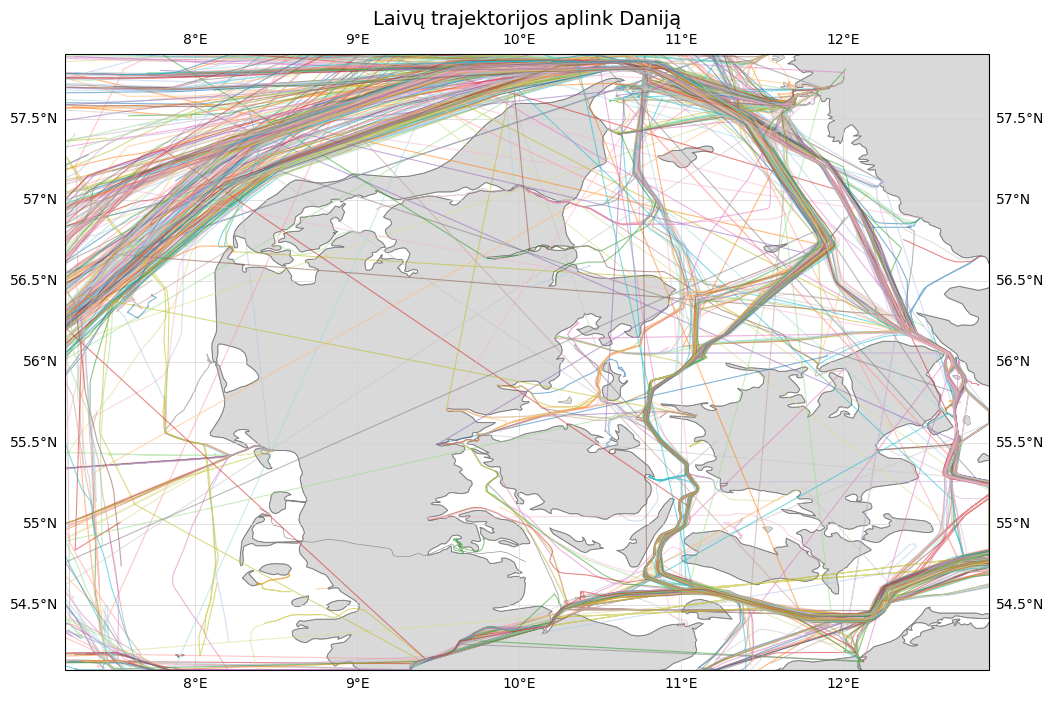

In [21]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# 1. Pasirenkam regioną aplink Daniją
lon_min, lon_max = 7.2, 12.9
lat_min, lat_max = 54.1, 57.9

# 2. Pasiliekam tik taškus tame regione
df_plot = df_ship[
    df_ship['longitude'].between(lon_min, lon_max) &
    df_ship['latitude'].between(lat_min, lat_max)
].copy()

# 3. Dėl greičio galima praretinti taškus
#    Pvz. kas 5-as taškas kiekvienam laivui
# df_plot = (
#     df_plot
#     .sort_values(['mmsi', 'timestamp'])
#     .groupby('mmsi', group_keys=False)
#     .apply(lambda g: g.iloc[::5])
#     .reset_index(drop=True)
# )

# 4. Braižymas
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Fonas
ax.set_facecolor('#f2f2f2')
ax.add_feature(cfeature.LAND, facecolor='#d9d9d9', edgecolor='gray', linewidth=0.6, zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor='white', zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7, edgecolor='gray')
ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor='gray')

# Tinklelis ir geografinės etiketės
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.6,
    color='lightgray',
    alpha=0.8,
    linestyle='-'
)
gl.top_labels = True
gl.right_labels = True
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# Spalvos trajektorijoms
cmap = plt.cm.tab20
mmsi_list = df_plot['mmsi'].drop_duplicates().tolist()

for i, mmsi in enumerate(mmsi_list):
    g = df_plot[df_plot['mmsi'] == mmsi]
    ax.plot(
        g['longitude'].values,
        g['latitude'].values,
        transform=ccrs.PlateCarree(),
        linewidth=0.8,
        alpha=0.55,
        color=cmap(i % 20)
    )

plt.title('Laivų trajektorijos aplink Daniją', fontsize=14)
plt.show()

In [23]:
numeric_cols = df_ship.select_dtypes(include='number')
print(numeric_cols.corr(method='pearson'))

                   mmsi  latitude  longitude       rot       sog       cog  \
mmsi           1.000000  0.001374  -0.038074 -0.000570  0.150261 -0.074307   
latitude       0.001374  1.000000  -0.248477  0.000851 -0.020600  0.062077   
longitude     -0.038074 -0.248477   1.000000  0.001064  0.045063  0.098125   
rot           -0.000570  0.000851   0.001064  1.000000 -0.000594  0.000607   
sog            0.150261 -0.020600   0.045063 -0.000594  1.000000 -0.076084   
cog           -0.074307  0.062077   0.098125  0.000607 -0.076084  1.000000   
heading       -0.064565  0.070771   0.099321 -0.000187 -0.013337  0.868860   
width          0.507175  0.015013  -0.061106 -0.000365  0.422206 -0.082717   
length         0.491852 -0.003997  -0.041832 -0.000250  0.510654 -0.092248   
draught        0.493271 -0.007351  -0.030332 -0.000604  0.376575 -0.014907   
a              0.500159  0.034915  -0.004974 -0.000213  0.420602 -0.072189   
b              0.101319 -0.055489  -0.060029 -0.000102  0.240712

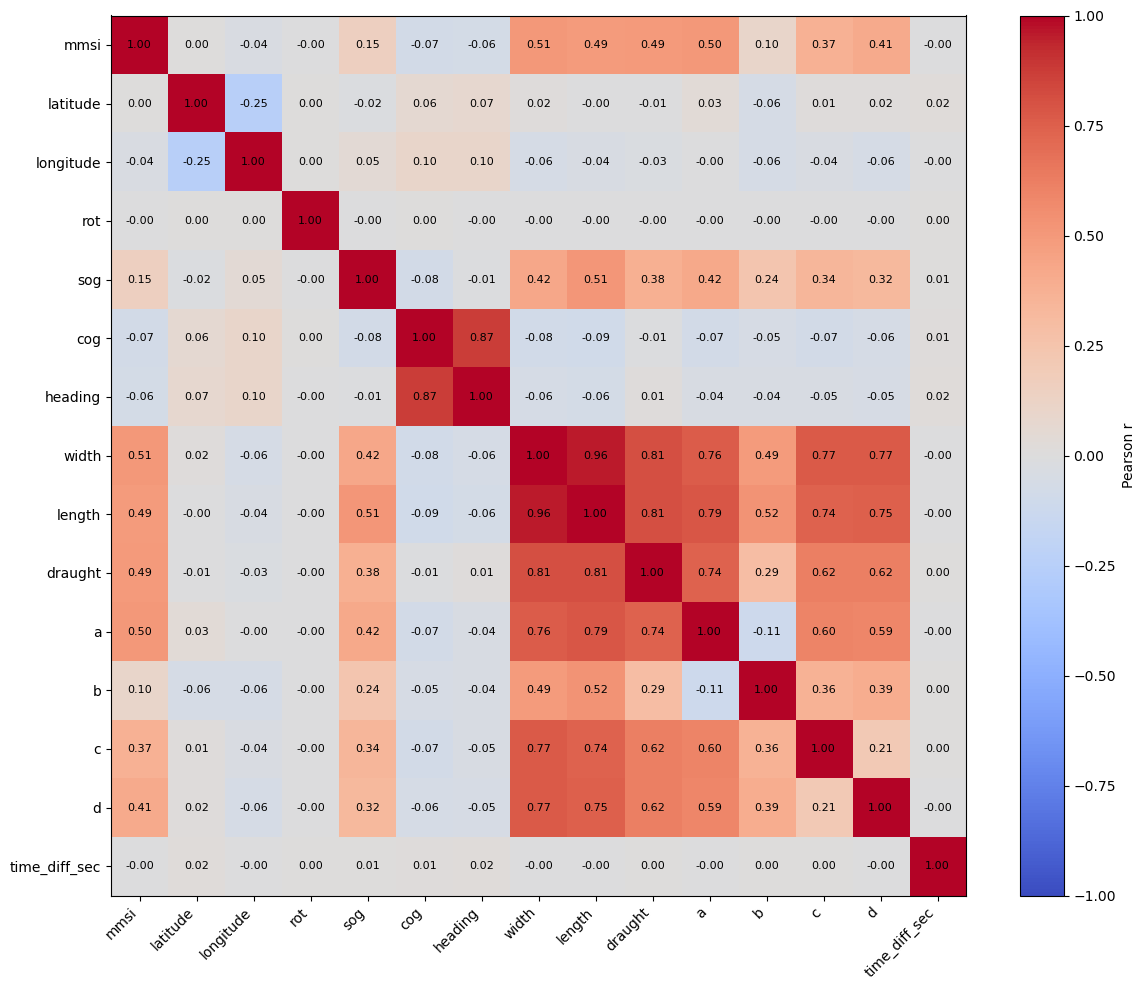

In [24]:
numeric_cols = df_ship.select_dtypes(include="number")
corr_matrix = numeric_cols.corr(method="pearson")

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_matrix.columns)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.colorbar(im, ax=ax, label="Pearson r")
plt.tight_layout()
plt.show()

In [25]:
df_ship = df_ship[['timestamp', 'mmsi', 'latitude', 'longitude']].copy()


In [26]:
df.groupby("ship_type").size()

ship_type
cargo     6890504
tanker    2460634
dtype: int64

In [27]:
# -----------------------------
# PARAMETERS
# -----------------------------
RESAMPLE_FREQ = '2min'
MAX_GAP = 3600  # 1 hour

# -----------------------------
# 1. SORT DATA
# -----------------------------
df = df_ship.sort_values(['mmsi', 'timestamp']).copy()

# -----------------------------
# 2. COMPUTE TIME GAPS
# -----------------------------
df['time_gap_sec'] = (
    df.groupby('mmsi')['timestamp']
    .diff()
    .dt.total_seconds()
)

# remove entire vessels if any gap is > 1 hour
bad_mmsi = df.loc[df['time_gap_sec'] > MAX_GAP, 'mmsi'].unique()
df = df[~df['mmsi'].isin(bad_mmsi)].copy()

# -----------------------------
# 3. RESAMPLING FUNCTION
# -----------------------------
# -----------------------------
# 3. RESAMPLING FUNCTION
# -----------------------------
def resample_ship(group, mmsi):
    if len(group) < 2:
        return None

    group = (
        group.sort_values('timestamp')
        .drop_duplicates('timestamp')
        .set_index('timestamp')
    )

    if group.index.min() == group.index.max():
        return None

    grid = pd.date_range(
        start=group.index.min().ceil(RESAMPLE_FREQ),
        end=group.index.max().floor(RESAMPLE_FREQ),
        freq=RESAMPLE_FREQ
    )

    if len(grid) == 0:
        return None

    tmp = group.reindex(group.index.union(grid)).sort_index()

    tmp[['latitude', 'longitude']] = (
        tmp[['latitude', 'longitude']]
        .interpolate(method='time', limit_area='inside')
    )

    tmp = tmp.loc[grid, ['latitude', 'longitude']].reset_index()
    tmp = tmp.rename(columns={'index': 'timestamp'})
    tmp['mmsi'] = mmsi

    return tmp[['timestamp', 'mmsi', 'latitude', 'longitude']]


# -----------------------------
# 4. APPLY
# -----------------------------
parts = []

for mmsi, group in df.groupby('mmsi'):
    res = resample_ship(group, mmsi)
    if res is not None and not res.empty:
        parts.append(res)

df_resampled = pd.concat(parts, ignore_index=True)

# -----------------------------
# RESULT
# -----------------------------
df_resampled.head()

,timestamp,mmsi,latitude,longitude
0,2025-05-17 00:14:00,205136000,55.498512,6.000735
1,2025-05-17 00:16:00,205136000,55.503229,6.003676
2,2025-05-17 00:18:00,205136000,55.507882,6.006539
3,2025-05-17 00:20:00,205136000,55.512645,6.009482
4,2025-05-17 00:22:00,205136000,55.517448,6.012406


In [28]:
df_ship['timestamp'].unique()

<DatetimeArray>
['2025-05-17 00:13:38', '2025-05-17 00:13:45', '2025-05-17 00:13:56',
 '2025-05-17 00:14:25', '2025-05-17 00:14:35', '2025-05-17 00:14:45',
 '2025-05-17 00:14:56', '2025-05-17 00:15:35', '2025-05-17 00:15:45',
 '2025-05-17 00:15:56',
 ...
 '2025-05-15 00:00:17', '2025-05-15 00:00:22', '2025-05-16 00:00:14',
 '2025-05-15 00:00:12', '2025-05-15 00:00:15', '2025-05-17 00:00:17',
 '2025-05-18 00:00:36', '2025-05-15 00:00:10', '2025-05-17 00:00:03',
 '2025-05-17 00:00:09']
Length: 260629, dtype: datetime64[ns]

----------------


In [29]:
# =============================
# TRAJECTORY WINDOWS / SEQUENCES
# =============================

WINDOW_SIZE = 20
STEP_SIZE = 10   # 50% overlap

# tik dėl saugumo
df_seq_src = (
    df_resampled[['timestamp', 'mmsi', 'latitude', 'longitude']]
    .sort_values(['mmsi', 'timestamp'])
    .reset_index(drop=True)
    .copy()
)

sequence_metadata = []
sequence_arrays = []
original_sequences = []

sequence_id = 0

for mmsi, group in df_seq_src.groupby('mmsi'):
    group = group.sort_values('timestamp').reset_index(drop=True)

    n = len(group)
    if n < WINDOW_SIZE:
        continue

    for start_idx in range(0, n - WINDOW_SIZE + 1, STEP_SIZE):
        end_idx = start_idx + WINDOW_SIZE

        window = group.iloc[start_idx:end_idx].copy()

        # 20x2 masyvas DTW etapui
        coords = window[['latitude', 'longitude']].to_numpy()

        start=coords[0]
        cords_relative = coords - start
        sequence_arrays.append(cords_relative)
        original_sequences.append(coords)

        sequence_metadata.append({
            'sequence_id': sequence_id,
            'mmsi': mmsi,
            'start_time': window['timestamp'].iloc[0],
            'end_time': window['timestamp'].iloc[-1],
            'window_start_idx': start_idx,
            'window_end_idx': end_idx - 1
        })

        sequence_id += 1

# metadata lentelė
sequence_metadata_df = pd.DataFrame(sequence_metadata)

print("Sekų skaičius:", len(sequence_arrays))
print("Metadata shape:", sequence_metadata_df.shape)
sequence_metadata_df.head()

Sekų skaičius: 27470
Metadata shape: (27470, 6)


,sequence_id,mmsi,start_time,end_time,window_start_idx,window_end_idx
0,0,205136000,2025-05-17 00:14:00,2025-05-17 00:52:00,0,19
1,1,205136000,2025-05-17 00:34:00,2025-05-17 01:12:00,10,29
2,2,205136000,2025-05-17 00:54:00,2025-05-17 01:32:00,20,39
3,3,205136000,2025-05-17 01:14:00,2025-05-17 01:52:00,30,49
4,4,205136000,2025-05-17 01:34:00,2025-05-17 02:12:00,40,59


In [30]:
# pirma seka
print(sequence_metadata_df.iloc[0])
print(sequence_arrays[0].shape)   # turėtų būti (20, 2)
print(sequence_arrays[0])

sequence_id                           0
mmsi                          205136000
start_time          2025-05-17 00:14:00
end_time            2025-05-17 00:52:00
window_start_idx                      0
window_end_idx                       19
Name: 0, dtype: object
(20, 2)
[[0.         0.        ]
 [0.00471666 0.00294144]
 [0.00936919 0.00580391]
 [0.01413266 0.00874749]
 [0.01893584 0.01167088]
 [0.02377338 0.0146887 ]
 [0.02850266 0.01764124]
 [0.03323066 0.0205525 ]
 [0.03800666 0.02348284]
 [0.04279288 0.02644579]
 [0.04759947 0.02941224]
 [0.05237232 0.03237324]
 [0.05721542 0.03536677]
 [0.06197747 0.03834297]
 [0.06678675 0.04130461]
 [0.07158556 0.04424779]
 [0.07640016 0.04722924]
 [0.08114146 0.05015624]
 [0.08594146 0.05312204]
 [0.09072986 0.05605764]]


In [31]:
sequence_metadata_df.groupby('mmsi').size().sort_values(ascending=False).head(10)

mmsi
207138000    142
205136000    142
304717000    142
636020533    142
636015170    142
563240400    142
210586000    142
354306000    142
257064430    142
244340000    142
dtype: int64

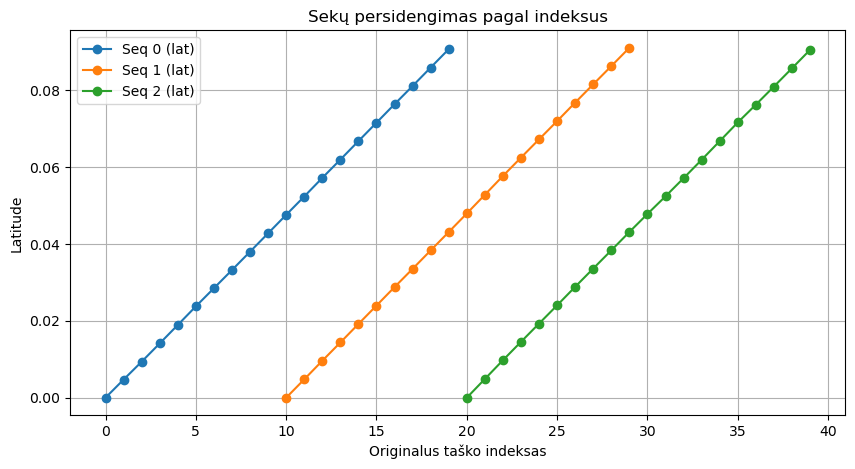

In [32]:
seq_ids = [0, 1, 2]

plt.figure(figsize=(10, 5))

for seq_id in seq_ids:
    coords = sequence_arrays[seq_id]
    start = sequence_metadata_df.iloc[seq_id]["window_start_idx"]
    x = np.arange(start, start + len(coords))

    plt.plot(x, coords[:, 0], marker='o', label=f'Seq {seq_id} (lat)')
    
plt.xlabel("Originalus taško indeksas")
plt.ylabel("Latitude")
plt.title("Sekų persidengimas pagal indeksus")
plt.legend()
plt.grid(True)
plt.show()

In [33]:
# kiek sekų turi kiekvienas laivas visame rinkinyje
all_vessel_seq_counts = sequence_metadata_df.groupby('mmsi').size()

# dažnių lentelė visam rinkiniui
all_freq_table = (
    all_vessel_seq_counts
    .value_counts()
    .sort_index(ascending=False)
    .reset_index()
)

all_freq_table.columns = ['n_sequences', 'n_vessels']
all_freq_table

,n_sequences,n_vessels
0,142,28
1,141,1
2,140,1
3,139,6
4,138,2
...,...,...
117,5,9
118,4,7
119,3,11
120,2,11


In [34]:
all_vessel_seq_counts.describe()

count    516.000000
mean      53.236434
std       43.183086
min        1.000000
25%       14.000000
50%       49.000000
75%       72.000000
max      142.000000
dtype: float64

In [35]:
# =============================
# FILTER VESSELS WITH AT LEAST 15 SEQUENCES
# =============================

MIN_SEQUENCES = 15

vessel_seq_counts_all = sequence_metadata_df.groupby('mmsi').size()

valid_mmsi = vessel_seq_counts_all[vessel_seq_counts_all >= MIN_SEQUENCES].index

filtered_metadata_df = (
    sequence_metadata_df[sequence_metadata_df['mmsi'].isin(valid_mmsi)]
    .sort_values(['mmsi', 'sequence_id'])
    .reset_index(drop=True)
    .copy()
)

filtered_sequence_ids = filtered_metadata_df['sequence_id'].tolist()
filtered_sequence_arrays = [sequence_arrays[i] for i in filtered_sequence_ids]
filtered_sequence_arrays_original = [original_sequences[i] for i in filtered_sequence_ids]

print("Laivų prieš filtrą:", sequence_metadata_df['mmsi'].nunique())
print("Laivų po filtro:", filtered_metadata_df['mmsi'].nunique())
print("Sekų prieš filtrą:", len(sequence_arrays))
print("Sekų po filtro:", len(filtered_sequence_arrays))


Laivų prieš filtrą: 516
Laivų po filtro: 383
Sekų prieš filtrą: 27470
Sekų po filtro: 26573


In [36]:
filtered_metadata_df.groupby('mmsi').size().describe()

count    383.000000
mean      69.381201
std       38.646280
min       15.000000
25%       35.000000
50%       70.000000
75%       91.500000
max      142.000000
dtype: float64

In [38]:
from tslearn.clustering import TimeSeriesKMeans


In [39]:
model = TimeSeriesKMeans(n_clusters=30, metric="dtw",
                         max_iter=10, random_state=RANDOM_STATE)

klasteriai=model.fit_predict(filtered_sequence_arrays)

In [40]:
print(filtered_metadata_df.shape)
print(klasteriai.shape)
print(np.unique(klasteriai, return_counts=True))
X = np.array(filtered_sequence_arrays)
print("lat min/max:", np.nanmin(X[:, :, 0]), np.nanmax(X[:, :, 0]))
print("lon min/max:", np.nanmin(X[:, :, 1]), np.nanmax(X[:, :, 1]))

print("pirma trajektorija:")
print(X[0][:5])

(26573, 6)
(26573,)
(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]), array([ 441, 1482, 2899, 1710, 1439, 1570,  569, 1027,    3, 1434,  929,
        908,    1, 1062,    1,    1, 1282, 1478,    2,  875,  924,  634,
        926,  778, 1210,    2, 1379, 1037,    4,  566]))
lat min/max: -1.0091651428571424 2.301965777777774
lon min/max: -5.366866166666665 4.959955261859582
pirma trajektorija:
[[0.         0.        ]
 [0.00471666 0.00294144]
 [0.00936919 0.00580391]
 [0.01413266 0.00874749]
 [0.01893584 0.01167088]]


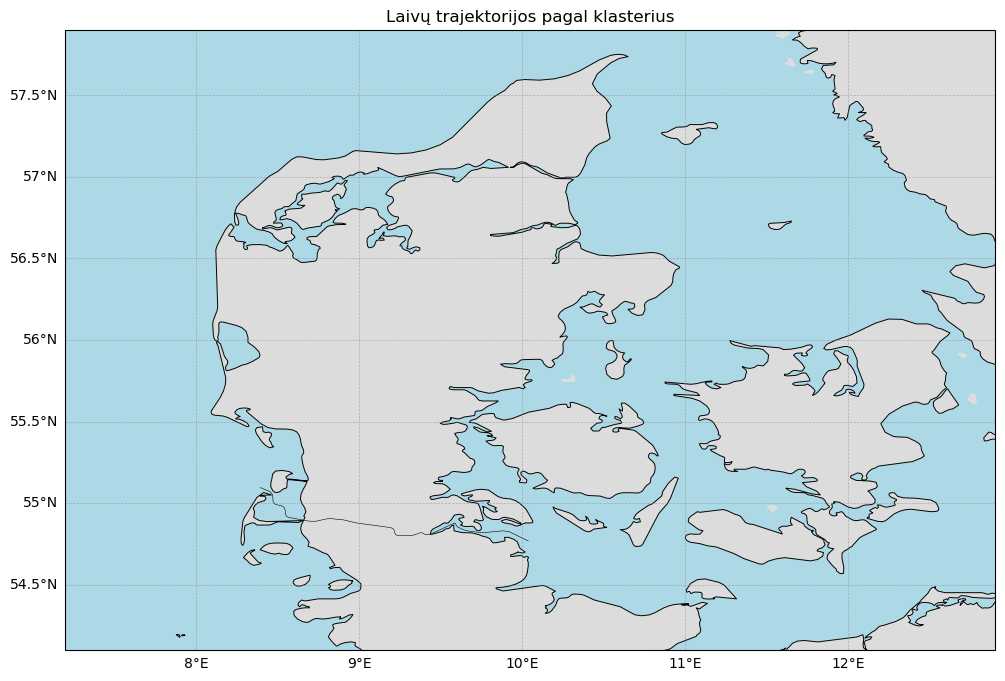

In [41]:
labels = np.array(klasteriai)

lon_min, lon_max = 7.2, 12.9
lat_min, lat_max = 54.1, 57.9

fig = plt.figure(figsize=(12, 9))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.LAND, facecolor="gainsboro")
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)

for i in range(len(X)):
    lat = X[i, :, 0]
    lon = X[i, :, 1]

    valid = np.isfinite(lon) & np.isfinite(lat)

    ax.plot(
        lon[valid],
        lat[valid],
        color=plt.cm.tab20(int(labels[i]) % 20),
        alpha=0.6,
        linewidth=1,
        transform=ccrs.PlateCarree()
    )

gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

ax.set_title("Laivų trajektorijos pagal klasterius")
plt.show()

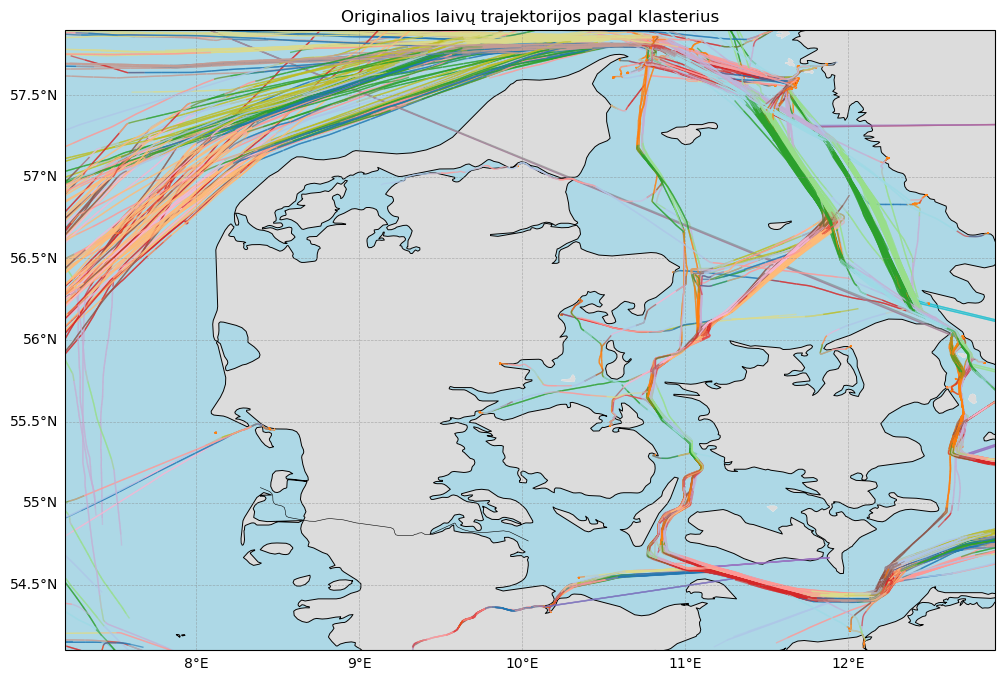

In [42]:

labels = np.array(klasteriai)             # klasteriai iš reliatyvių sekų
X = np.array(filtered_sequence_arrays_original)  # originalios lat/lon sekos

lon_min, lon_max = 7.2, 12.9
lat_min, lat_max = 54.1, 57.9

fig = plt.figure(figsize=(12, 9))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.LAND, facecolor="gainsboro")
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)

for i in range(len(X)):
    lat = X[i, :, 0]
    lon = X[i, :, 1]

    valid = np.isfinite(lon) & np.isfinite(lat)

    ax.plot(
        lon[valid],
        lat[valid],
        color=plt.cm.tab20(int(labels[i]) % 20),
        alpha=0.6,
        linewidth=1,
        transform=ccrs.PlateCarree()
    )

gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

ax.set_title("Originalios laivų trajektorijos pagal klasterius")
plt.show()

In [43]:
print("len(labels):", len(labels))
print("len(X):", len(X))
print("labels shape:", labels.shape)
print("X shape:", X.shape)

len(labels): 26573
len(X): 26573
labels shape: (26573,)
X shape: (26573, 20, 2)


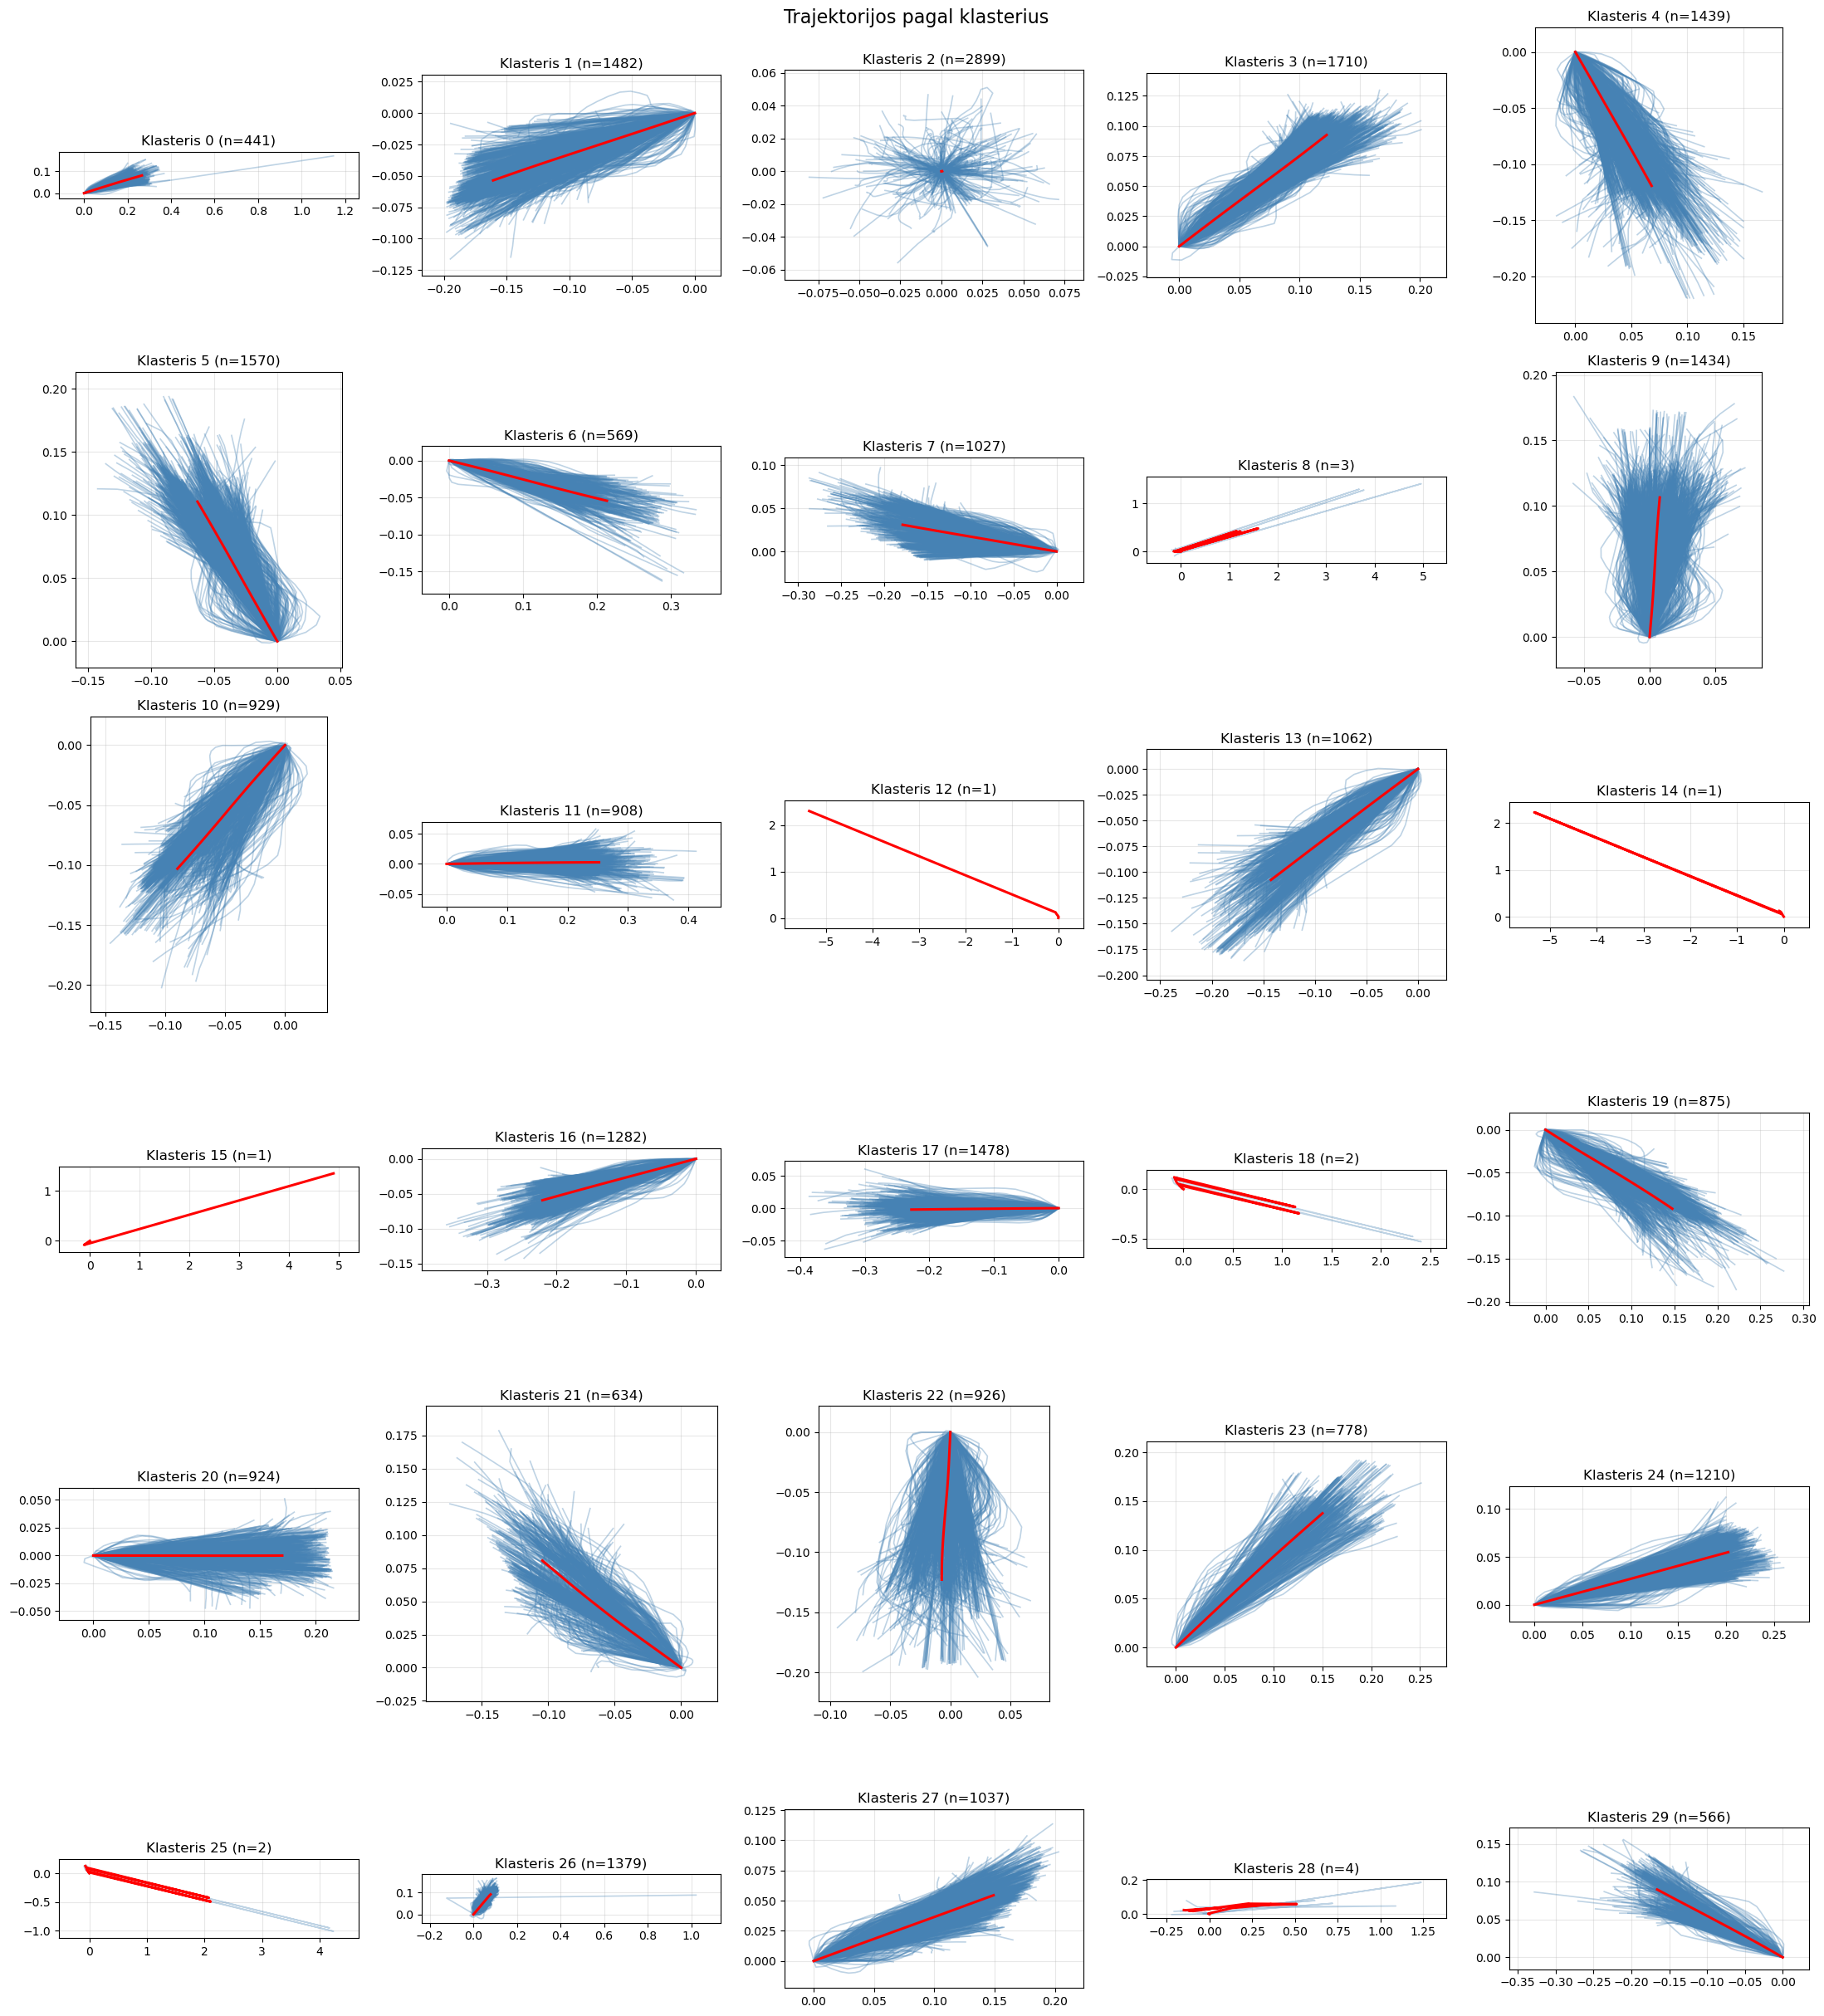

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import math

X = np.array(filtered_sequence_arrays)
labels = np.array(klasteriai)

n_clusters = len(np.unique(labels))
n_cols = 5
n_rows = math.ceil(n_clusters / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 4.2 * n_rows), sharex=False, sharey=False)
axes = np.array(axes).reshape(-1)

for k in range(n_clusters):
    ax = axes[k]
    idx = np.where(labels == k)[0]

    all_lon = []
    all_lat = []

    for i in idx:
        coords = X[i]
        lat = coords[:, 0]
        lon = coords[:, 1]
        valid = np.isfinite(lat) & np.isfinite(lon)

        if valid.any():
            ax.plot(lon[valid], lat[valid], color='steelblue', alpha=0.35, linewidth=1.2)
            all_lon.extend(lon[valid])
            all_lat.extend(lat[valid])

    if len(idx) > 0:
        mean_traj = np.nanmean(X[idx], axis=0)
        valid_mean = np.isfinite(mean_traj[:, 0]) & np.isfinite(mean_traj[:, 1])
        ax.plot(mean_traj[valid_mean, 1], mean_traj[valid_mean, 0], color='red', linewidth=2.2)

    if len(all_lon) > 0 and len(all_lat) > 0:
        xmin, xmax = np.min(all_lon), np.max(all_lon)
        ymin, ymax = np.min(all_lat), np.max(all_lat)

        xpad = max((xmax - xmin) * 0.1, 0.001)
        ypad = max((ymax - ymin) * 0.1, 0.001)

        ax.set_xlim(xmin - xpad, xmax + xpad)
        ax.set_ylim(ymin - ypad, ymax + ypad)

    ax.set_title(f'Klasteris {k} (n={len(idx)})')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')

for j in range(n_clusters, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Trajektorijos pagal klasterius', fontsize=16)
plt.tight_layout()
plt.show()

In [47]:
print(df.columns.tolist())

['timestamp', 'mmsi', 'latitude', 'longitude', 'time_gap_sec']


In [45]:
print("Po sujungimo:", df['mmsi'].nunique())

tmp = df.copy()
tmp = tmp[tmp['ship_type'].isin(['cargo', 'tanker'])]
print("Po ship_type filtro:", tmp['mmsi'].nunique())

tmp = tmp[tmp['type_of_mobile'].isin(['Class A', 'Class B'])]
print("Po type_of_mobile filtro:", tmp['mmsi'].nunique())

bad_coords = tmp.loc[tmp['latitude'] > 90, 'mmsi'].unique()
tmp = tmp[~tmp['mmsi'].isin(bad_coords)]
print("Po blogų koordinačių filtro:", tmp['mmsi'].nunique())

tmp = tmp.sort_values(['mmsi', 'timestamp']).copy()
tmp['time_gap_sec'] = tmp.groupby('mmsi')['timestamp'].diff().dt.total_seconds()

bad_gap = tmp.loc[tmp['time_gap_sec'] > 3600, 'mmsi'].unique()
tmp = tmp[~tmp['mmsi'].isin(bad_gap)]
print("Po >1h gap filtro:", tmp['mmsi'].nunique())

Po sujungimo: 554


KeyError: 'ship_type'